In [ ]:
# Install required packages
# Gerekli paketlerin kurulumu
!pip install -q albumentations lightgbm openpyxl

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Paths
# Yollar
DATA_ROOT = "/content/drive/MyDrive/mini_dataset_2000"
OUTPUT_ROOT = "/content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

CLASSES = ["a", "b", "c", "d"]

# Paper hyperparameters (Nguyen et al., IEEE EMBC 2022)
# Makale hiperparametreleri
IMG_SIZE = 512                # ResNet-34 icin makale boyutu
BATCH_SIZE = 16
MAX_EPOCHS = 50
PATIENCE = 10
LR = 1e-4                     # SGD baslangic
MOMENTUM = 0.9                # makale
SEED = 42

# Split (patient-wise, paper does not use CV)
# Split (hasta bazli, makale CV kullanmiyor)
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.80, 0.10, 0.10

assert os.path.exists(DATA_ROOT), f"DATA_ROOT bulunamadi: {DATA_ROOT}"
print("Veri dizini:", DATA_ROOT)
print(f"Makale ayarlari: ResNet-34, {IMG_SIZE}x{IMG_SIZE}, SGD (lr {LR}, momentum {MOMENTUM})")
print("Iki asamali: CNN oznitelik cikarimi -> LightGBM siniflandirma")

Veri dizini: /content/drive/MyDrive/mini_dataset_2000
Makale ayarlari: ResNet-34, 512x512, SGD (lr 0.0001, momentum 0.9)
Iki asamali: CNN oznitelik cikarimi -> LightGBM siniflandirma


In [ ]:
import pandas as pd

def parse_filename(fname):
    base = os.path.splitext(fname)[0]
    parts = base.split("_")
    if len(parts) != 2:
        return None
    pid = parts[0]
    code = parts[1].upper()
    side, view = code[0], code[1:]
    if side not in ["L", "R"] or view not in ["CC", "MLO"]:
        return None
    return pid, side, view

rows = []
for label in CLASSES:
    class_dir = os.path.join(DATA_ROOT, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(".png"):
            continue
        parsed = parse_filename(fname)
        if parsed is None:
            continue
        pid, side, view = parsed
        rows.append({"patient_id": pid, "side": side, "view": view,
                     "label": label, "filepath": os.path.join(class_dir, fname)})

df = pd.DataFrame(rows)

# Breast-level table (paper predicts per breast, using that breast's CC and MLO)
# Meme bazli tablo (makale meme basina tahmin yapar, o memenin CC ve MLO'su ile)
breast_df = df.pivot_table(index=["patient_id", "side", "label"],
                           columns="view", values="filepath", aggfunc="first").reset_index()
breast_df.columns.name = None
breast_df = breast_df.rename(columns={"CC": "cc_path", "MLO": "mlo_path"})

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
breast_df["label_idx"] = breast_df["label"].map(label_to_idx)

print("Toplam goruntu:", len(df))
print("Toplam meme:", len(breast_df))
print("\nSinif dagilimi:")
print(breast_df["label"].value_counts())

Toplam goruntu: 8000
Toplam meme: 4000

Sinif dagilimi:
label
b    1414
c    1398
d     694
a     494
Name: count, dtype: int64


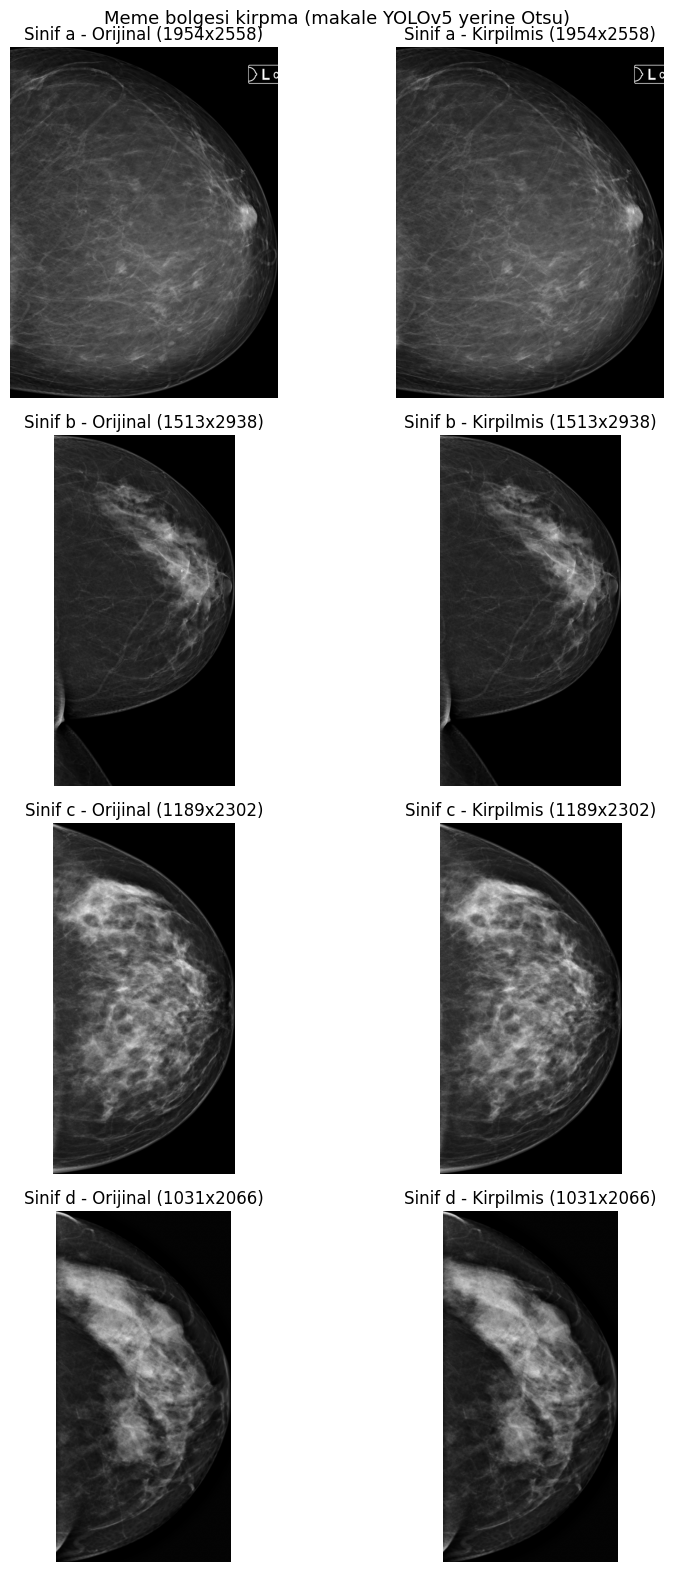

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Background threshold: only separate black background, keep all tissue
# Arka plan esigi: sadece siyah arka plani ayir, tum dokuyu koru
BG_THRESH = 10
MORPH_KERNEL = 9

def crop_breast(img_gray, padding_ratio=0.05):
    # Breast region cropping (paper uses YOLOv5; we use Otsu-based cropping)
    # Meme bolgesi kirpma (makale YOLOv5 kullanir; biz Otsu tabanli kirpma)
    # Only x-axis is cropped, full height preserved to keep tissue intact
    # Sadece x ekseni kirpilir, doku butunlugu icin tum yukseklik korunur
    h_img, w_img = img_gray.shape

    _, binary = cv2.threshold(img_gray, BG_THRESH, 255, cv2.THRESH_BINARY)

    disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, disk)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
    if num_labels <= 1:
        return img_gray

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    component = (labels == largest).astype(np.uint8)

    ys, xs = np.where(component > 0)
    if len(xs) == 0:
        return img_gray

    x, x_max = xs.min(), xs.max()
    w = x_max - x
    if w < 0.35 * w_img:
        return img_gray

    pad_x = int(w * padding_ratio)
    x1 = max(0, x - pad_x)
    x2 = min(w_img, x_max + pad_x)

    # Crop from original, full height
    # Orijinalden kirp, tam yukseklik
    return img_gray[:, x1:x2]

# Visual check on one sample per class
# Sinif basina bir ornekte gorsel kontrol
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(9, 4 * len(CLASSES)))
for row_i, cls in enumerate(CLASSES):
    r = breast_df[breast_df["label"] == cls].iloc[0]
    img = cv2.imread(r["cc_path"], cv2.IMREAD_GRAYSCALE)
    cropped = crop_breast(img)

    axes[row_i, 0].imshow(img, cmap="gray")
    axes[row_i, 0].set_title(f"Sinif {cls} - Orijinal ({img.shape[1]}x{img.shape[0]})")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(cropped, cmap="gray")
    axes[row_i, 1].set_title(f"Sinif {cls} - Kirpilmis ({cropped.shape[1]}x{cropped.shape[0]})")
    axes[row_i, 1].axis("off")

plt.suptitle("Meme bolgesi kirpma (makale YOLOv5 yerine Otsu)", fontsize=13)
plt.tight_layout()
plt.show()

sadece ilk seferde çalıştır

In [ ]:
import os
import shutil
from tqdm import tqdm

# Local fast disk for processing
# Isleme icin hizli lokal disk
LOCAL_PROC = "/content/dataset_nguyen"
os.makedirs(LOCAL_PROC, exist_ok=True)

# Final destination on Drive
# Drive uzerindeki nihai hedef
PROC_ROOT = os.path.join(OUTPUT_ROOT, "dataset_processed")

def preprocess_and_save(src_path, label):
    # Crop breast region, resize to 512x512, save as grayscale PNG
    # Meme bolgesini kirp, 512x512'ye getir, gri tonlamali PNG kaydet
    # Channel duplication to RGB happens later in the Dataset (paper method)
    # RGB'ye kanal kopyalama daha sonra Dataset icinde yapilir (makale yontemi)
    fname = os.path.basename(src_path)
    dst_dir = os.path.join(LOCAL_PROC, label)
    os.makedirs(dst_dir, exist_ok=True)
    dst_path = os.path.join(dst_dir, fname)

    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Okunamadi: {src_path}")
        return None

    cropped = crop_breast(img)
    resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    cv2.imwrite(dst_path, resized)
    return dst_path

# Step 1: process to local disk
# Adim 1: lokal diske isle
print("Adim 1/2: Lokal diske isleniyor...")
cc_paths, mlo_paths = [], []
for _, row in tqdm(breast_df.iterrows(), total=len(breast_df)):
    cc_paths.append(preprocess_and_save(row["cc_path"], row["label"]))
    mlo_paths.append(preprocess_and_save(row["mlo_path"], row["label"]))

# Step 2: bulk copy to Drive
# Adim 2: Drive'a toplu kopyala
print("\nAdim 2/2: Drive'a toplu kopyalaniyor...")
if os.path.exists(PROC_ROOT):
    shutil.rmtree(PROC_ROOT)
shutil.copytree(LOCAL_PROC, PROC_ROOT)
print("Kopyalama tamamlandi.")

# Map to Drive paths
# Drive yollarina cevir
def to_drive(p):
    return p.replace(LOCAL_PROC, PROC_ROOT) if p else None

breast_df["cc_proc"] = [to_drive(p) for p in cc_paths]
breast_df["mlo_proc"] = [to_drive(p) for p in mlo_paths]

n_missing = breast_df["cc_proc"].isna().sum() + breast_df["mlo_proc"].isna().sum()
print(f"\nEksik kayit: {n_missing}")

table_path = os.path.join(OUTPUT_ROOT, "breast_table.csv")
breast_df.to_csv(table_path, index=False)
print(f"Tablo kaydedildi: {table_path}")
print(f"Islenmis goruntuler: {PROC_ROOT}")

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# Patient-wise stratified split, 80/10/10 (paper protocol)
# Hasta bazli stratified split, 80/10/10 (makale protokolu)
np.random.seed(SEED)

X = np.arange(len(breast_df))
y = breast_df["label_idx"].values
groups = breast_df["patient_id"].values

# Separate test (10%)
# Test ayir (%10)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(iter(sgkf.split(X, y, groups)))

# Separate val (10% of total) from trainval
# Trainval icinden val ayir (toplam %10)
sgkf2 = StratifiedGroupKFold(n_splits=9, shuffle=True, random_state=SEED)
tr_rel, val_rel = next(iter(sgkf2.split(trainval_idx, y[trainval_idx], groups[trainval_idx])))

train_idx = trainval_idx[tr_rel]
val_idx = trainval_idx[val_rel]

breast_df["split"] = "train"
breast_df.loc[val_idx, "split"] = "val"
breast_df.loc[test_idx, "split"] = "test"

print("Split boyutlari:")
print(breast_df["split"].value_counts())

# Verify no patient leakage
# Hasta sizintisi kontrolu
tr_p = set(breast_df[breast_df["split"] == "train"]["patient_id"])
va_p = set(breast_df[breast_df["split"] == "val"]["patient_id"])
te_p = set(breast_df[breast_df["split"] == "test"]["patient_id"])
assert not (tr_p & va_p) and not (tr_p & te_p) and not (va_p & te_p), "Sizinti var!"
print("\nSizinti yok, dogrulandi.")

print("\nSplit basina sinif dagilimi (%):")
print((breast_df.groupby("split")["label"].value_counts(normalize=True).unstack() * 100).round(1))

# Save table with splits
# Split ile tabloyu kaydet
table_path = os.path.join(OUTPUT_ROOT, "breast_table.csv")
breast_df.to_csv(table_path, index=False)
print(f"\nTablo kaydedildi: {table_path}")

Split boyutlari:
split
train    3200
test      400
val       400
Name: count, dtype: int64

Sizinti yok, dogrulandi.

Split basina sinif dagilimi (%):
label     a     b     c     d
split                        
test   11.5  37.0  33.5  18.0
train  12.1  35.1  35.2  17.6
val    15.0  35.5  34.5  15.0

Tablo kaydedildi: /content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/breast_table.csv


In [ ]:
import os
import pandas as pd

# Rebuild the processed paths from the file naming convention
# Dosya isimlendirme kuralindan islenmis yollari yeniden olustur
# Processed images already exist on Drive, only the table lost the columns
# Islenmis goruntuler Drive'da mevcut, sadece tablo sutunlari kayboldu
PROC_ROOT = os.path.join(OUTPUT_ROOT, "dataset_processed")

def build_proc_path(orig_path, label):
    # Processed images keep the same filename, in class subfolder
    # Islenmis goruntuler ayni dosya adini korur, sinif alt klasorunde
    fname = os.path.basename(orig_path)
    return os.path.join(PROC_ROOT, label, fname)

breast_df["cc_proc"] = breast_df.apply(
    lambda r: build_proc_path(r["cc_path"], r["label"]), axis=1
)
breast_df["mlo_proc"] = breast_df.apply(
    lambda r: build_proc_path(r["mlo_path"], r["label"]), axis=1
)

# Verify the files actually exist
# Dosyalarin gercekten var oldugunu dogrula
missing_cc = (~breast_df["cc_proc"].apply(os.path.exists)).sum()
missing_mlo = (~breast_df["mlo_proc"].apply(os.path.exists)).sum()

print(f"Eksik CC dosyasi: {missing_cc}")
print(f"Eksik MLO dosyasi: {missing_mlo}")

assert missing_cc == 0 and missing_mlo == 0, "Islenmis goruntuler bulunamadi!"

# Save the fixed table
# Duzeltilmis tabloyu kaydet
table_path = os.path.join(OUTPUT_ROOT, "breast_table.csv")
breast_df.to_csv(table_path, index=False)

print("\nIslenmis yollar yeniden olusturuldu ve kaydedildi.")
print("Sutunlar:", breast_df.columns.tolist())
print("\nOrnek yol:", breast_df["cc_proc"].iloc[0])

Eksik CC dosyasi: 0
Eksik MLO dosyasi: 0

Islenmis yollar yeniden olusturuldu ve kaydedildi.
Sutunlar: ['patient_id', 'side', 'label', 'cc_path', 'mlo_path', 'label_idx', 'split', 'cc_proc', 'mlo_proc']

Ornek yol: /content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/dataset_processed/d/822670188_LCC.png


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Strong augmentation to prevent overfitting
# Overfitting'i onlemek icin guclu augmentation
# Same strategy that worked for TwoViewDensityNet on this dataset
# Bu veri setinde TwoViewDensityNet'te ise yarayan ayni strateji
train_transform = A.Compose([
    A.Rotate(limit=180, border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Guclu augmentation hazir (180 rotasyon + yatay/dikey flip).")

class SingleViewDataset(Dataset):
    # Stage 1: CNN is trained on individual views (paper approach)
    # Asama 1: CNN tekil gorunumler uzerinde egitilir (makale yaklasimi)
    # Each image (CC or MLO) is a separate training sample
    # Her goruntu (CC veya MLO) ayri bir egitim ornegidir

    def __init__(self, dataframe, transform):
        # Expand breast-level rows into per-view rows
        # Meme bazli satirlari gorunum bazli satirlara ac
        records = []
        for _, r in dataframe.iterrows():
            records.append({"path": r["cc_proc"], "label_idx": r["label_idx"]})
            records.append({"path": r["mlo_proc"], "label_idx": r["label_idx"]})
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        # Read grayscale, duplicate to 3 channels (paper method)
        # Gri tonlamali oku, 3 kanala kopyala (makale yontemi)
        img = cv2.imread(rec["path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Okunamadi: {rec['path']}")
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = self.transform(image=img)["image"]
        return img, int(rec["label_idx"])

train_df = breast_df[breast_df["split"] == "train"].copy()
val_df = breast_df[breast_df["split"] == "val"].copy()
test_df = breast_df[breast_df["split"] == "test"].copy()

train_loader = DataLoader(SingleViewDataset(train_df, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                          pin_memory=True, drop_last=True)
val_loader = DataLoader(SingleViewDataset(val_df, eval_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Asama 1 DataLoader'lari hazir (tek gorunum).")
print(f"Train goruntu: {len(train_loader.dataset)}")
print(f"Val goruntu: {len(val_loader.dataset)}")

img, lbl = next(iter(train_loader))
print(f"\nGoruntu: {img.shape}, etiket: {lbl[:8].tolist()}")

Guclu augmentation hazir (180 rotasyon + yatay/dikey flip).
Asama 1 DataLoader'lari hazir (tek gorunum).
Train goruntu: 6400
Val goruntu: 800

Goruntu: torch.Size([16, 3, 512, 512]), etiket: [1, 1, 2, 2, 3, 2, 1, 2]


In [ ]:
import torch.nn as nn
import torchvision.models as models

class ResNet34FeatureExtractor(nn.Module):
    # Stage 1 model: ResNet-34 trained as a classifier
    # Asama 1 modeli: siniflandirici olarak egitilen ResNet-34
    # After training, the FC layer is removed and GAP output is used as features
    # Egitim sonrasi FC katmani kaldirilir, GAP ciktisi oznitelik olarak kullanilir

    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        backbone = models.resnet34(
            weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        )
        # Keep everything except the final FC
        # Son FC haric her seyi tut
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        # ResNet-34 outputs 512-dim after GAP
        # ResNet-34 GAP sonrasi 512 boyut uretir
        self.feat_dim = 512
        self.classifier = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x, return_features=False):
        # Extract features
        # Oznitelik cikar
        f = self.features(x)
        f = torch.flatten(f, 1)   # B, 512

        if return_features:
            return f
        return self.classifier(f)

# Quick test
# Hizli test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cihaz:", device)

_m = ResNet34FeatureExtractor(num_classes=4).to(device)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    _out = _m(_x)
    _feat = _m(_x, return_features=True)
print("Sinif ciktisi:", _out.shape)      # [2, 4]
print("Oznitelik ciktisi:", _feat.shape)  # [2, 512]
print("Parametre:", sum(p.numel() for p in _m.parameters()) / 1e6, "M")

del _m, _x
torch.cuda.empty_cache()

Cihaz: cuda
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 145MB/s]


Sinif ciktisi: torch.Size([2, 4])
Oznitelik ciktisi: torch.Size([2, 512])
Parametre: 21.286724 M


In [ ]:
import torch.optim as optim
import os
import shutil

# Local dir for checkpoints (avoid Drive freeze)
# Checkpoint icin lokal dizin (Drive donmasini onle)
LOCAL_OUT = "/content/local_out_nguyen"
os.makedirs(LOCAL_OUT, exist_ok=True)
SYNC_EVERY = 5

LAST_CKPT = os.path.join(LOCAL_OUT, "last.pt")
BEST_CKPT = os.path.join(LOCAL_OUT, "best.pt")
EXCEL_LOG = os.path.join(LOCAL_OUT, "log.xlsx")
DRIVE_CKPT_DIR = os.path.join(OUTPUT_ROOT, "stage1_cnn")

model = ResNet34FeatureExtractor(num_classes=4, pretrained=True).to(device)

# Paper: cross-entropy loss, SGD momentum 0.9, cosine annealing
# Makale: cross-entropy loss, SGD momentum 0.9, cosine annealing
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

def save_ckpt(path, epoch, model, optimizer, scheduler, best_val_loss, no_improve):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "no_improve": no_improve,
    }, path)

def sync_to_drive(local_dir, drive_dir):
    # Copy only needed files, no rmtree (avoids Drive freeze)
    # Sadece gerekli dosyalari kopyala, rmtree yok (Drive donmasini onler)
    os.makedirs(drive_dir, exist_ok=True)
    for fname in ["last.pt", "best.pt", "log.xlsx"]:
        src = os.path.join(local_dir, fname)
        if not os.path.exists(src):
            continue
        try:
            shutil.copy2(src, os.path.join(drive_dir, fname))
        except Exception as e:
            print(f"  Uyari: {fname} Drive'a yazilamadi ({e})")

# Resume
# Devam
start_epoch, best_val_loss, no_improve = 0, float("inf"), 0

if not os.path.exists(LAST_CKPT) and os.path.exists(os.path.join(DRIVE_CKPT_DIR, "last.pt")):
    sync_to_drive(DRIVE_CKPT_DIR, LOCAL_OUT)
    print("Drive'dan checkpoint cekildi.")

if os.path.exists(LAST_CKPT):
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model_state"])
    optimizer.load_state_dict(ck["optimizer_state"])
    scheduler.load_state_dict(ck["scheduler_state"])
    start_epoch = ck["epoch"] + 1
    best_val_loss = ck["best_val_loss"]
    no_improve = ck["no_improve"]
    print(f"Checkpoint bulundu. Epoch {start_epoch}'dan devam.")
else:
    print("Asama 1: Sifirdan baslaniyor.")

# Mixed precision scaler for faster training on T4 tensor cores
# T4 tensor core'lari ile daha hizli egitim icin mixed precision scaler
from torch.amp import GradScaler
scaler = GradScaler("cuda")
print("Mixed precision (AMP) aktif.")

print(f"\nAsama 1 kurulumu: ResNet-34, SGD (lr {LR}, momentum {MOMENTUM}), cosine annealing")

Drive'dan checkpoint cekildi.
Checkpoint bulundu. Epoch 29'dan devam.
Mixed precision (AMP) aktif.

Asama 1 kurulumu: ResNet-34, SGD (lr 0.0001, momentum 0.9), cosine annealing


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp import autocast
from sklearn.metrics import accuracy_score, f1_score

@torch.no_grad()
def evaluate_single_view(model, loader, criterion, device):
    # Evaluate the stage-1 CNN on individual views, with mixed precision
    # Asama 1 CNN'ini tekil gorunumler uzerinde degerlendir, mixed precision ile
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for x, labels in loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward in mixed precision for speed
        # Hiz icin mixed precision ile ileri gecis
        with autocast("cuda"):
            outputs = model(x)
            loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        all_preds.append(outputs.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
    }

print("Metrik fonksiyonu hazir (AMP).")

In [ ]:
from tqdm import tqdm
from torch.amp import autocast
import pandas as pd

# Load log, drop epochs >= start_epoch to avoid duplicates on resume
# Logu yukle, resume'da tekrari onlemek icin start_epoch ve sonrasini at
if os.path.exists(EXCEL_LOG):
    _df = pd.read_excel(EXCEL_LOG)
    _df = _df[_df["epoch"] < start_epoch]
    log_rows = _df.to_dict("records")
else:
    log_rows = []

def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    # Training with automatic mixed precision (AMP)
    # Otomatik mixed precision (AMP) ile egitim
    # Forward runs in float16, gradients are scaled to avoid underflow
    # Ileri gecis float16, gradyanlar underflow'u onlemek icin olceklenir
    model.train()
    total_loss = 0.0

    for x, labels in tqdm(loader, desc="Train", leave=False):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward in mixed precision
        # Mixed precision ile ileri gecis
        with autocast("cuda"):
            outputs = model(x)
            loss = criterion(outputs, labels)

        # Scaled backward and optimizer step
        # Olceklenmis geri yayilim ve optimizer adimi
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)

    return total_loss / len(loader.dataset)

print("ASAMA 1: CNN oznitelik cikarici egitimi")
print(f"Epoch {start_epoch} -> {MAX_EPOCHS - 1}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    # Train with AMP
    # AMP ile egit
    train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)

    # Evaluate
    # Degerlendir
    tr_m = evaluate_single_view(model, train_loader, criterion, device)
    va_m = evaluate_single_view(model, val_loader, criterion, device)

    # Step scheduler
    # Scheduler adimi
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    print(f"E{epoch:02d} | tr_loss {tr_m['loss']:.3f} acc {tr_m['accuracy']:.3f} | "
          f"va_loss {va_m['loss']:.3f} acc {va_m['accuracy']:.3f} f1 {va_m['macro_f1']:.3f} | "
          f"lr {lr:.1e}")

    # Log row
    # Log satiri
    row = {"epoch": epoch, "lr": lr}
    for k, v in tr_m.items():
        row[f"train_{k}"] = v
    for k, v in va_m.items():
        row[f"val_{k}"] = v
    log_rows.append(row)
    pd.DataFrame(log_rows).to_excel(EXCEL_LOG, index=False)

    # Best checkpoint on val loss
    # Val loss temelli en iyi checkpoint
    if va_m["loss"] < best_val_loss:
        best_val_loss = va_m["loss"]
        no_improve = 0
        save_ckpt(BEST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, no_improve)
        print(f"  -> Yeni en iyi val loss: {best_val_loss:.4f}")
    else:
        no_improve += 1
        print(f"  -> Iyilesme yok ({no_improve}/{PATIENCE})")

    save_ckpt(LAST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, no_improve)

    # Periodic Drive sync
    # Periyodik Drive senkronizasyonu
    if (epoch + 1) % SYNC_EVERY == 0:
        sync_to_drive(LOCAL_OUT, DRIVE_CKPT_DIR)
        print("  (Drive'a senkronize edildi)")

    # Early stopping
    # Erken durdurma
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping: {PATIENCE} epoch iyilesme yok.")
        break

# Final sync
# Son senkronizasyon
sync_to_drive(LOCAL_OUT, DRIVE_CKPT_DIR)

print(f"\nAsama 1 tamamlandi. En iyi val loss: {best_val_loss:.4f}")

Aşama 2

In [ ]:
import numpy as np
import torch
from torch.amp import autocast
from torch.utils.data import Dataset, DataLoader
import cv2
from tqdm import tqdm

# Load the best stage-1 model (lowest val loss)
# En iyi asama-1 modelini yukle (en dusuk val loss)
ck = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ck["model_state"])
model.eval()
print(f"Asama 1 en iyi model yuklendi (epoch {ck['epoch']}, val_loss {ck['best_val_loss']:.4f})")

class ViewPathDataset(Dataset):
    # Returns a single image from a given path, no augmentation
    # Verilen yoldan tek goruntu dondurur, augmentation yok

    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Okunamadi: {self.paths[idx]}")
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return self.transform(image=img)["image"]

@torch.no_grad()
def extract_features(paths, model, device, batch_size=32):
    # Extract 512-dim GAP features for a list of image paths
    # Bir goruntu yolu listesi icin 512 boyutlu GAP oznitelikleri cikar
    loader = DataLoader(ViewPathDataset(paths, eval_transform),
                        batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    feats = []
    for x in tqdm(loader, desc="Oznitelik cikariliyor", leave=False):
        x = x.to(device, non_blocking=True)
        with autocast("cuda"):
            f = model(x, return_features=True)
        feats.append(f.float().cpu().numpy())
    return np.concatenate(feats)

# Extract features for CC and MLO of every breast
# Her memenin CC ve MLO'su icin oznitelik cikar
print("\nCC oznitelikleri cikariliyor...")
cc_feats = extract_features(breast_df["cc_proc"].tolist(), model, device)

print("MLO oznitelikleri cikariliyor...")
mlo_feats = extract_features(breast_df["mlo_proc"].tolist(), model, device)

print(f"\nCC oznitelik sekli: {cc_feats.shape}")
print(f"MLO oznitelik sekli: {mlo_feats.shape}")

# Paper fusion: average the CC and MLO feature vectors of the same breast
# Makale fuzyonu: ayni memenin CC ve MLO oznitelik vektorlerini ortala
fused_feats = (cc_feats + mlo_feats) / 2.0
print(f"Birlestirilmis oznitelik sekli: {fused_feats.shape}")

# Save features to Drive
# Oznitelikleri Drive'a kaydet
feat_path = os.path.join(OUTPUT_ROOT, "features.npz")
np.savez(feat_path,
         cc=cc_feats, mlo=mlo_feats, fused=fused_feats,
         labels=breast_df["label_idx"].values,
         splits=breast_df["split"].values)
print(f"\nOznitelikler kaydedildi: {feat_path}")

Asama 1 en iyi model yuklendi (epoch 18, val_loss 0.5883)

CC oznitelikleri cikariliyor...


MLO oznitelikleri cikariliyor...



CC oznitelik sekli: (4000, 512)
MLO oznitelik sekli: (4000, 512)
Birlestirilmis oznitelik sekli: (4000, 512)

Oznitelikler kaydedildi: /content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/features.npz


In [ ]:
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score, roc_auc_score)

# Split fused features by set
# Birlestirilmis oznitelikleri sete gore ayir
splits = breast_df["split"].values
labels = breast_df["label_idx"].values

X_train = fused_feats[splits == "train"]
y_train = labels[splits == "train"]
X_val = fused_feats[splits == "val"]
y_val = labels[splits == "val"]
X_test = fused_feats[splits == "test"]
y_test = labels[splits == "test"]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Train LightGBM on the fused CNN features (paper stage 2)
# Birlestirilmis CNN oznitelikleri uzerinde LightGBM egit (makale asama 2)
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    "objective": "multiclass",
    "num_class": 4,
    "metric": "multi_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1,
    "seed": SEED,
}

print("\nLightGBM egitiliyor...")
gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
print(f"En iyi iterasyon: {gbm.best_iteration}")

# Evaluate on test set
# Test setinde degerlendir
probs_test = gbm.predict(X_test, num_iteration=gbm.best_iteration)
preds_test = probs_test.argmax(axis=1)

print("\n" + "=" * 55)
print("ASAMA 2 TEST SONUCLARI (CNN + LightGBM fuzyon)")
print("=" * 55)
print(f"Accuracy:        {accuracy_score(y_test, preds_test):.4f}")
print(f"Macro F1:        {f1_score(y_test, preds_test, average='macro'):.4f}")
print(f"Macro AUC:       {roc_auc_score(y_test, probs_test, multi_class='ovr', average='macro'):.4f}")
print(f"Cohen Kappa:     {cohen_kappa_score(y_test, preds_test):.4f}")
print(f"Weighted Kappa:  {cohen_kappa_score(y_test, preds_test, weights='quadratic'):.4f}")

print("\n=== Siniflandirma Raporu ===")
print(classification_report(y_test, preds_test, target_names=CLASSES, digits=3))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, preds_test)
print(pd.DataFrame(cm,
                   index=[f"gercek_{c}" for c in CLASSES],
                   columns=[f"tahmin_{c}" for c in CLASSES]))

# Save the LightGBM model
# LightGBM modelini kaydet
gbm.save_model(os.path.join(OUTPUT_ROOT, "lightgbm_model.txt"))
print("\nLightGBM modeli kaydedildi.")

Train: (3200, 512), Val: (400, 512), Test: (400, 512)

LightGBM egitiliyor...
[100]	valid_0's multi_logloss: 0.736744
En iyi iterasyon: 50

ASAMA 2 TEST SONUCLARI (CNN + LightGBM fuzyon)
Accuracy:        0.7700
Macro F1:        0.7569
Macro AUC:       0.9383
Cohen Kappa:     0.6754
Weighted Kappa:  0.8639

=== Siniflandirma Raporu ===
              precision    recall  f1-score   support

           a      0.615     0.696     0.653        46
           b      0.793     0.750     0.771       148
           c      0.775     0.799     0.787       134
           d      0.829     0.806     0.817        72

    accuracy                          0.770       400
   macro avg      0.753     0.762     0.757       400
weighted avg      0.773     0.770     0.771       400

=== Confusion Matrix ===
          tahmin_a  tahmin_b  tahmin_c  tahmin_d
gercek_a        32        14         0         0
gercek_b        20       111        17         0
gercek_c         0        15       107        12
gercek_

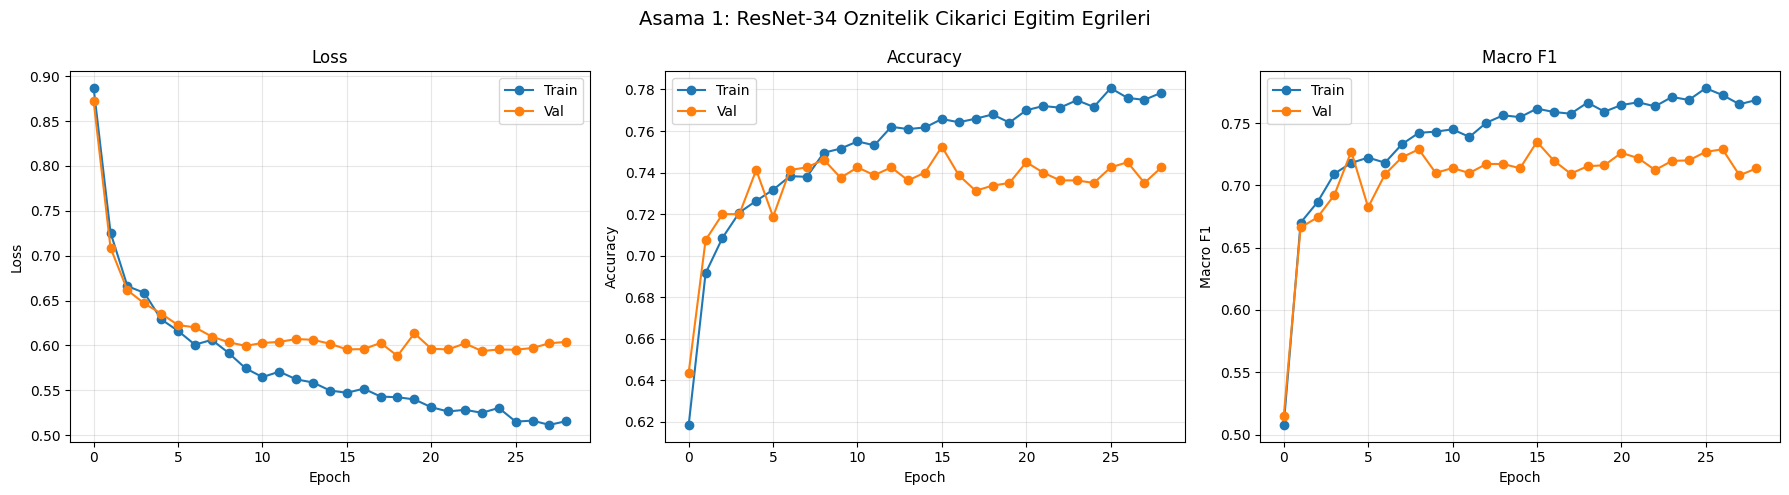

Kaydedildi: /content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/stage1_training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Read the stage-1 training log
# Asama 1 egitim logunu oku
log_path = os.path.join(DRIVE_CKPT_DIR, "log.xlsx")
if not os.path.exists(log_path):
    log_path = EXCEL_LOG   # lokal kopya
log_df = pd.read_excel(log_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, [("loss", "Loss"),
                                       ("accuracy", "Accuracy"),
                                       ("macro_f1", "Macro F1")]):
    ax.plot(log_df["epoch"], log_df[f"train_{metric}"], marker="o", label="Train")
    ax.plot(log_df["epoch"], log_df[f"val_{metric}"], marker="o", label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Asama 1: ResNet-34 Oznitelik Cikarici Egitim Egrileri", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_ROOT, "stage1_training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

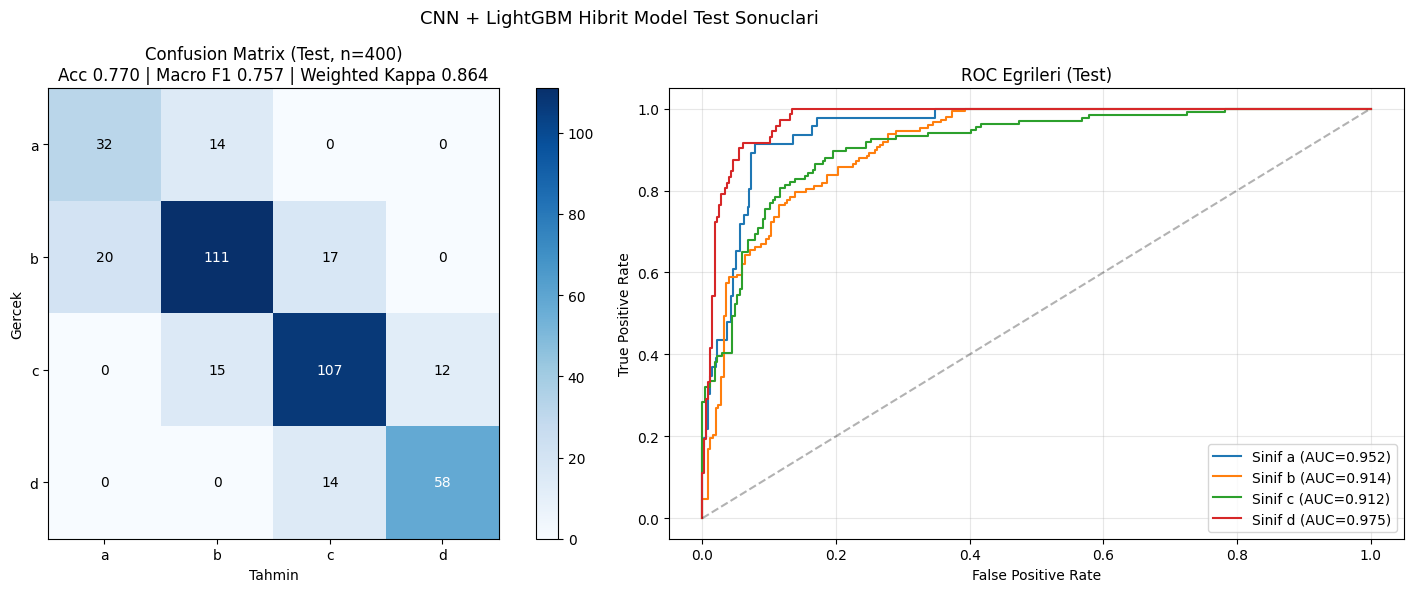

Kaydedildi: /content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/stage2_confusion_roc.png

=== Kritik hata kontrolu ===
Gercek a, tahmin d: 0
Gercek d, tahmin a: 0
(a ve d gorsel olarak zit kutuplar, karisma minimum olmali)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score, cohen_kappa_score
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
# Karisiklik matrisi
cm = confusion_matrix(y_test, preds_test)
im = axes[0].imshow(cm, cmap="Blues")

acc = accuracy_score(y_test, preds_test)
mf1 = f1_score(y_test, preds_test, average="macro")
wk = cohen_kappa_score(y_test, preds_test, weights="quadratic")

axes[0].set_title(f"Confusion Matrix (Test, n={len(y_test)})\n"
                  f"Acc {acc:.3f} | Macro F1 {mf1:.3f} | Weighted Kappa {wk:.3f}")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gercek")
axes[0].set_xticks(range(len(CLASSES)))
axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASSES)
axes[0].set_yticklabels(CLASSES)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# ROC curves per class
# Sinif basina ROC egrileri
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"Sinif {c} (AUC={roc_auc:.3f})")

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC Egrileri (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("CNN + LightGBM Hibrit Model Test Sonuclari", fontsize=13)
plt.tight_layout()

save_path = os.path.join(OUTPUT_ROOT, "stage2_confusion_roc.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

# Critical error check
# Kritik hata kontrolu
a_i, d_i = CLASSES.index("a"), CLASSES.index("d")
print(f"\n=== Kritik hata kontrolu ===")
print(f"Gercek a, tahmin d: {cm[a_i, d_i]}")
print(f"Gercek d, tahmin a: {cm[d_i, a_i]}")
print("(a ve d gorsel olarak zit kutuplar, karisma minimum olmali)")

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def train_and_eval_lgb(X_tr, y_tr, X_v, y_v, X_te, y_te, name):
    # Train LightGBM on a given feature set and report test metrics
    # Verilen oznitelik seti uzerinde LightGBM egit ve test metriklerini raporla
    lgb_tr = lgb.Dataset(X_tr, label=y_tr)
    lgb_v = lgb.Dataset(X_v, label=y_v, reference=lgb_tr)

    params = {"objective": "multiclass", "num_class": 4,
              "metric": "multi_logloss", "learning_rate": 0.05,
              "num_leaves": 31, "verbose": -1, "seed": SEED}

    m = lgb.train(params, lgb_tr, num_boost_round=1000, valid_sets=[lgb_v],
                  callbacks=[lgb.early_stopping(50, verbose=False)])

    probs = m.predict(X_te, num_iteration=m.best_iteration)
    preds = probs.argmax(axis=1)

    return {
        "Konfigurasyon": name,
        "Accuracy": accuracy_score(y_te, preds),
        "Macro F1": f1_score(y_te, preds, average="macro"),
        "Weighted Kappa": cohen_kappa_score(y_te, preds, weights="quadratic"),
    }

# Compare: CC only, MLO only, and fused (paper's claim)
# Karsilastir: sadece CC, sadece MLO, ve birlestirilmis (makalenin iddiasi)
tr_m, va_m, te_m = splits == "train", splits == "val", splits == "test"

results = []
for feats, name in [(cc_feats, "Sadece CC"),
                    (mlo_feats, "Sadece MLO"),
                    (fused_feats, "CC + MLO fuzyon")]:
    results.append(train_and_eval_lgb(
        feats[tr_m], labels[tr_m],
        feats[va_m], labels[va_m],
        feats[te_m], labels[te_m],
        name
    ))

results_df = pd.DataFrame(results)
print("=" * 60)
print("FUZYON ABLATION (makalenin ana iddiasinin testi)")
print("=" * 60)
print(results_df.round(4).to_string(index=False))

# Save
# Kaydet
results_df.to_csv(os.path.join(OUTPUT_ROOT, "fusion_ablation.csv"), index=False)
print(f"\nKaydedildi: {os.path.join(OUTPUT_ROOT, 'fusion_ablation.csv')}")

FUZYON ABLATION (makalenin ana iddiasinin testi)
  Konfigurasyon  Accuracy  Macro F1  Weighted Kappa
      Sadece CC    0.7675    0.7612          0.8538
     Sadece MLO    0.7200    0.6995          0.8238
CC + MLO fuzyon    0.7700    0.7569          0.8639

Kaydedildi: /content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/fusion_ablation.csv


Grad-CAM hazir (Asama 1 CNN, epoch 18).

=== Sinif basina bir test ornegi ===



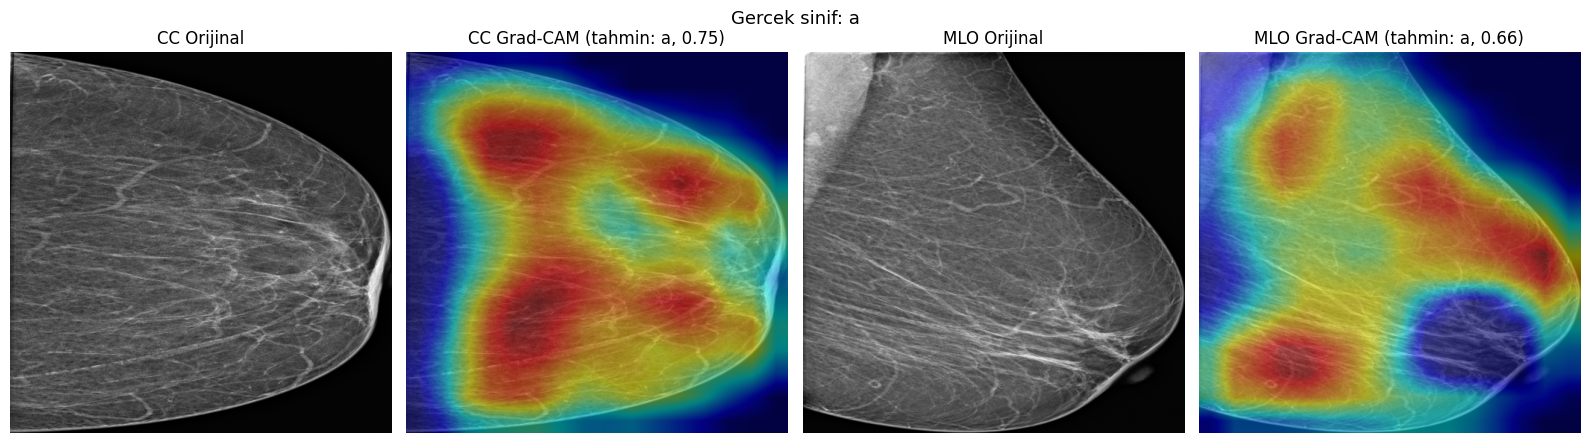

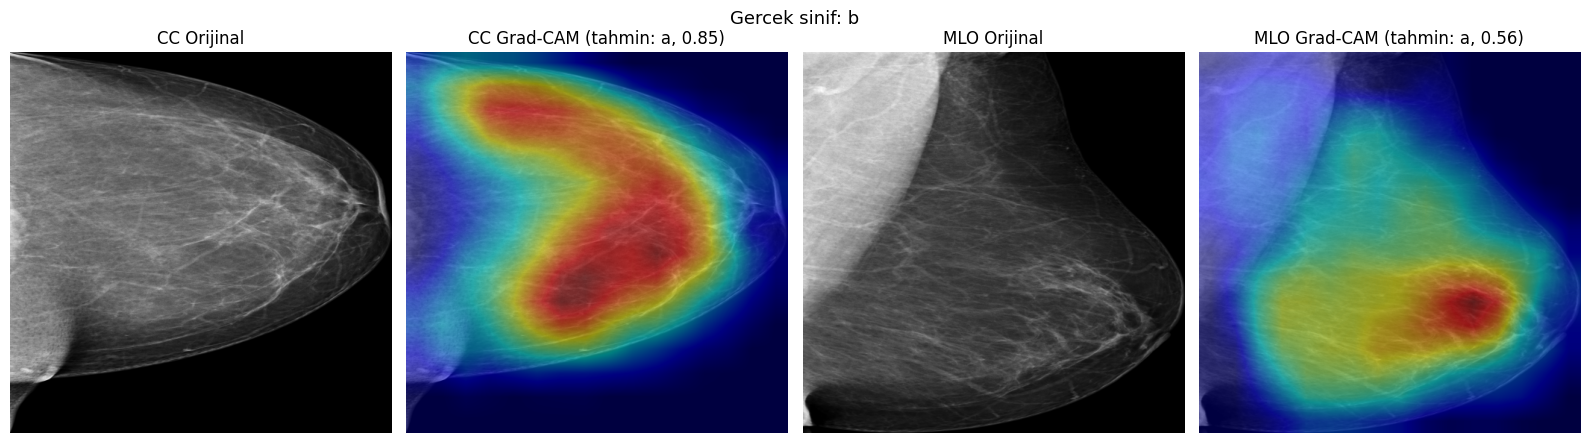

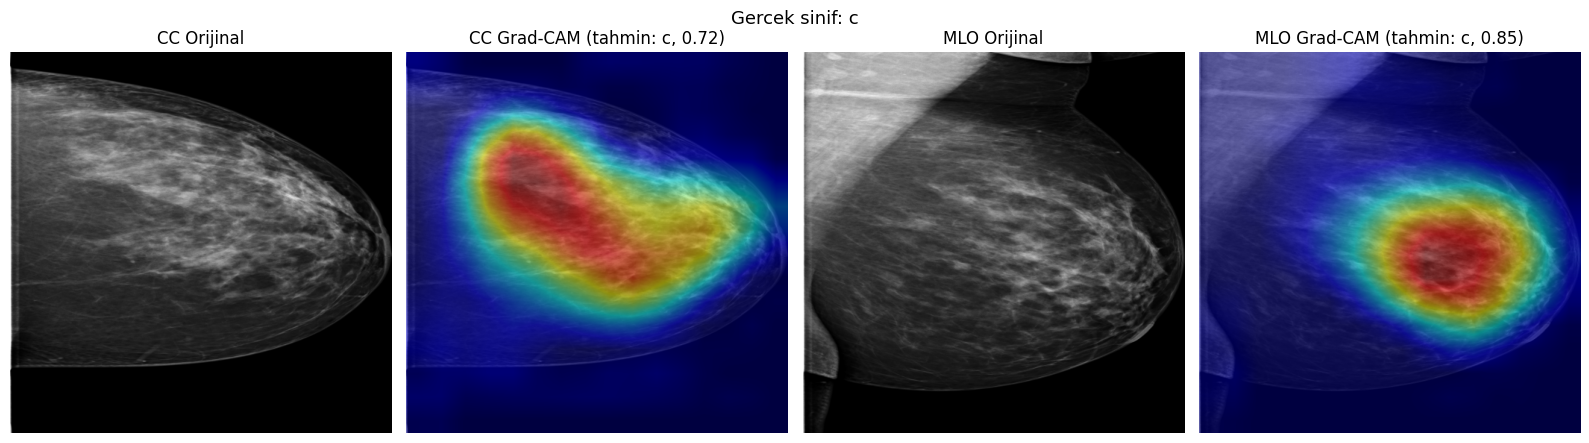

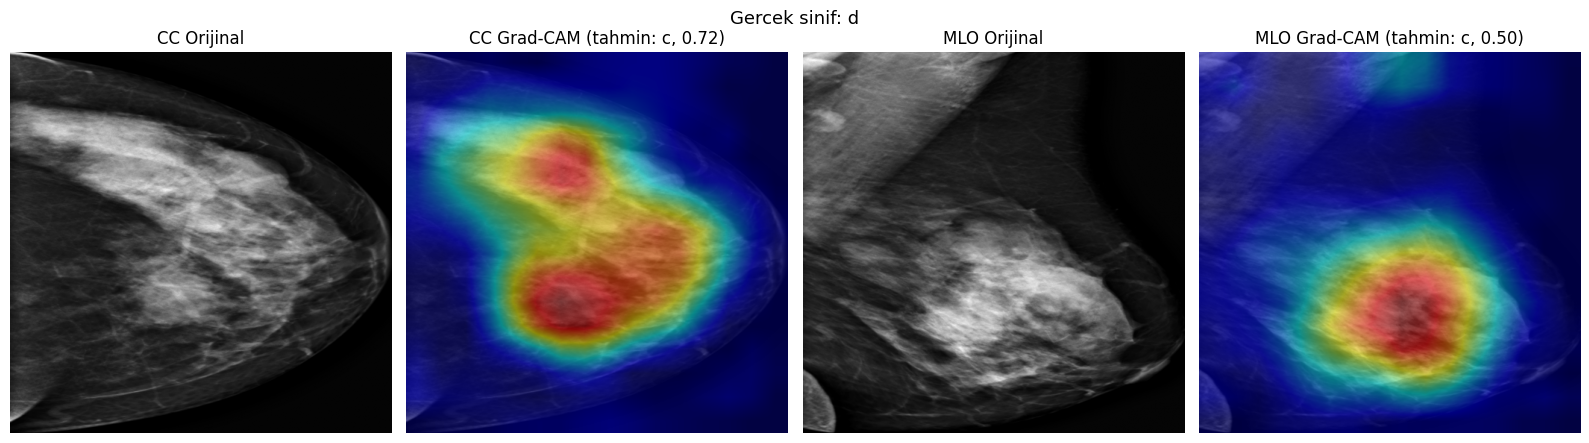

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    # Grad-CAM for the single-view ResNet-34 feature extractor
    # Tek gorunumlu ResNet-34 oznitelik cikarici icin Grad-CAM
    # Note: LightGBM has no conv layers, so Grad-CAM applies to the CNN stage only
    # Not: LightGBM'de conv katmani yok, Grad-CAM sadece CNN asamasina uygulanir

    def __init__(self, model):
        self.model = model
        self.model.eval()

        # Last conv block of ResNet-34 is layer4 (index 7 in features Sequential)
        # ResNet-34'un son conv blogu layer4 (features icinde 7. indeks)
        self.target_layer = model.features[7]

        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x, target_class=None):
        # Forward pass through the classifier head
        # Siniflandirma basligindan ileri gecis
        output = self.model(x)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Backward on the target class score
        # Hedef sinif skoru uzerinden geri yayilim
        self.model.zero_grad()
        output[0, target_class].backward()

        # Channel importance = mean gradient over spatial dims
        # Kanal onemi = uzamsal boyutlar uzerinde ortalama gradyan
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        probs = F.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, target_class, probs

def overlay_cam(img_rgb, cam, alpha=0.5):
    # Overlay the heatmap on the image
    # Isi haritasini goruntu uzerine bindir
    cam_resized = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha * heatmap + (1 - alpha) * img_rgb)

# Load the best stage-1 model
# En iyi asama-1 modelini yukle
ck = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ck["model_state"])
model.eval()

gradcam = GradCAM(model)
print(f"Grad-CAM hazir (Asama 1 CNN, epoch {ck['epoch']}).")

def visualize_breast(row):
    # Show CC and MLO with their Grad-CAM heatmaps
    # CC ve MLO'yu Grad-CAM isi haritalari ile goster
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

    for i, (view, path) in enumerate([("CC", row["cc_proc"]), ("MLO", row["mlo_proc"])]):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        x = eval_transform(image=img_rgb)["image"].unsqueeze(0).to(device)
        cam, pred_cls, probs = gradcam.generate(x)

        axes[i * 2].imshow(img, cmap="gray")
        axes[i * 2].set_title(f"{view} Orijinal")
        axes[i * 2].axis("off")

        axes[i * 2 + 1].imshow(overlay_cam(img_rgb, cam))
        axes[i * 2 + 1].set_title(f"{view} Grad-CAM (tahmin: {CLASSES[pred_cls]}, {probs[pred_cls]:.2f})")
        axes[i * 2 + 1].axis("off")

    plt.suptitle(f"Gercek sinif: {row['label']}", fontsize=13)
    plt.tight_layout()
    plt.show()

# Show one example per class from the test set
# Test setinden sinif basina bir ornek goster
test_rows = breast_df[breast_df["split"] == "test"]

print("\n=== Sinif basina bir test ornegi ===\n")
for cls in CLASSES:
    cls_rows = test_rows[test_rows["label"] == cls]
    if len(cls_rows) > 0:
        visualize_breast(cls_rows.iloc[0])